In [1]:
from virtualizarr import open_virtual_dataset
import pandas as pd
import json
import numpy as np
import base64
import xarray as xr
from virtualizarr.parsers import ZarrParser
from obstore.store import LocalStore
from virtualizarr.registry import ObjectStoreRegistry

/tmp/ipykernel_3987435/1216142460.py:9: DeprecationWarning: Importing ObjectStoreRegistry from VirtualiZarr is deprecated. Please use 'from obspec_utils.registry import ObjectStoreRegistry instead.
  from virtualizarr.registry import ObjectStoreRegistry


In [2]:
dates = pd.date_range("1993-01-01", "2024-12-31", freq="D")
dates

DatetimeIndex(['1993-01-01', '1993-01-02', '1993-01-03', '1993-01-04',
               '1993-01-05', '1993-01-06', '1993-01-07', '1993-01-08',
               '1993-01-09', '1993-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[us]', length=11688, freq='D')

In [4]:
import nest_asyncio

nest_asyncio.apply()

In [8]:
# Load the averaged dataset to get its references
# First, open ds_averaged as virtual dataset to extract kerchunk references
zarr_store_avg = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/data/climatology/S_daily_climatology_365days.zarr"
store_avg = LocalStore(prefix=zarr_store_avg)
registry_avg = ObjectStoreRegistry({f"file://{zarr_store_avg}": store_avg})
parser = ZarrParser()
vds_avg = open_virtual_dataset(url=zarr_store_avg, registry=registry_avg, parser=parser)
refs_avg = vds_avg.vz.to_kerchunk()

print("Averaged dataset refs loaded")
print(
    f"Number of dayofyear chunks: {len([k for k in refs_avg['refs'].keys() if k.startswith('vosaline/') and '.0.0' in k])}"
)

Averaged dataset refs loaded
Number of dayofyear chunks: 366


In [9]:
# Create new refs dict based on dates time dimension but referencing ds_averaged chunks
new_refs = {"version": 1, "refs": {}}

# Copy basic metadata
new_refs["refs"][".zgroup"] = refs_avg["refs"][".zgroup"]
new_refs["refs"][".zattrs"] = refs_avg["refs"][".zattrs"]

# Copy coordinate arrays and metadata for spatial dimensions
for key in refs_avg["refs"].keys():
    if key.startswith(("deptht/", "y/", "x/")):
        new_refs["refs"][key] = refs_avg["refs"][key]

# Get dayofyear info from ds_averaged
dayofyear_array_metadata = json.loads(
    refs_avg["refs"][".zarray"]
    if ".zarray" in refs_avg["refs"]
    else refs_avg["refs"].get("dayofyear/.zarray", "{}")
)
n_times = len(dates)

# Get day of year for each date in the full date range
dayofyear_values = pd.DatetimeIndex(dates).dayofyear

print(f"Total time steps in dates: {n_times}")
print(f"Day of year range: {dayofyear_values.min()} to {dayofyear_values.max()}")
print(f"Number of unique day of years: {len(np.unique(dayofyear_values))}")

Total time steps in dates: 11688
Day of year range: 1 to 366
Number of unique day of years: 366


In [10]:
# Map temperature chunks: each time step references the corresponding dayofyear chunk
# Identify the temperature variable name in the averaged dataset
temp_var = "vosaline"  # Change this if your variable has a different name

# Reference date
ref_date = np.datetime64("1993-01-01")

# Convert dates to days since reference date
time_values = (dates.values - ref_date) / np.timedelta64(1, "D")
time_values = time_values.astype(np.int64)

# Base64 encode the time data
time_bytes = time_values.tobytes()
time_b64 = base64.b64encode(time_bytes).decode("ascii")

# Create zarr metadata for time coordinate
time_zarray_metadata = {
    "chunks": [len(dates)],  # Use full length as chunk size
    "compressor": None,
    "dtype": "<i8",
    "fill_value": None,
    "filters": None,
    "order": "C",
    "shape": [len(dates)],
    "zarr_format": 2,
}

time_zattrs = {
    "_ARRAY_DIMENSIONS": ["time_counter"],
    "calendar": "proleptic_gregorian",
    "units": "days since 1993-01-01 00:00:00",
    "time_origin": "1950-JAN-01 00:00:00",
}

# Store time coordinate in refs with base64 encoding
new_refs["refs"]["time_counter/.zarray"] = json.dumps(time_zarray_metadata)
new_refs["refs"]["time_counter/.zattrs"] = json.dumps(time_zattrs)
new_refs["refs"]["time_counter/0"] = f"base64:{time_b64}"

# Get the metadata from ds_averaged for the temperature variable
temp_array_metadata = json.loads(refs_avg["refs"][f"{temp_var}/.zarray"])
n_dayofyear = temp_array_metadata["shape"][0]

# Map each time step to the corresponding dayofyear chunk
for time_idx in range(n_times):
    # Get the day of year for this time step (1-indexed)
    doy = dayofyear_values[time_idx]

    # dayofyear is 1-indexed (1-366), but zarr chunks are 0-indexed
    # So doy 1 maps to chunk 0, doy 2 maps to chunk 1, etc.
    doy_chunk_idx = doy - 1

    # Reference the corresponding dayofyear chunk from ds_averaged
    new_key = f"{temp_var}/{time_idx}.0.0.0"
    avg_key = f"{temp_var}/{doy_chunk_idx}.0.0.0"

    if avg_key in refs_avg["refs"]:
        new_refs["refs"][new_key] = refs_avg["refs"][avg_key]
    else:
        print(f"Warning: {avg_key} not found in averaged refs")

# Update temperature metadata with new time dimension size
temp_array_metadata["shape"] = [
    n_times,
    temp_array_metadata["shape"][1],
    temp_array_metadata["shape"][2],
    temp_array_metadata["shape"][3],
]

new_refs["refs"][f"{temp_var}/.zarray"] = json.dumps(temp_array_metadata)

# Update temperature attributes to use 'time' dimension instead of 'dayofyear'
temp_attrs = json.loads(refs_avg["refs"][f"{temp_var}/.zattrs"])
temp_attrs["_ARRAY_DIMENSIONS"] = [
    "time_counter",
    "deptht",
    "y",
    "x",
]  # Update dimension names
new_refs["refs"][f"{temp_var}/.zattrs"] = json.dumps(temp_attrs)

print("\nNew refs created:")
print(f"  Time dimension: {n_times} steps (full date range)")
print(f"  Temperature shape: {temp_array_metadata['shape']}")
print("  Temperature chunks mapped from ds_averaged based on day of year")


New refs created:
  Time dimension: 11688 steps (full date range)
  Temperature shape: [11688, 50, 601, 501]
  Temperature chunks mapped from ds_averaged based on day of year


In [11]:
# Write the new refs to JSON
refs_json_path = "../data/climatology_refs_S.json"

with open(refs_json_path, "w") as f:
    json.dump(new_refs, f, indent=2)

print(f"Climatology refs written to: {refs_json_path}")

Climatology refs written to: ../data/climatology_refs_S.json


In [12]:
ds_climatology = xr.open_dataset(
    "reference://",
    engine="zarr",
    backend_kwargs={"consolidated": False},
    storage_options={"fo": refs_json_path},
)

ds_climatology

<xarray.Dataset> Size: 1TB
Dimensions:       (time_counter: 11688, deptht: 50, y: 601, x: 501)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 94kB 1993-01-01 ... 2024-12-31
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * y             (y) int32 2kB 2300 2301 2302 2303 2304 ... 2897 2898 2899 2900
  * x             (x) int32 2kB 3000 3001 3002 3003 3004 ... 3497 3498 3499 3500
Data variables:
    vosaline      (time_counter, deptht, y, x) float64 1TB ...

In [8]:
ds_climatology = xr.open_dataset(
    "reference://",
    engine="zarr",
    backend_kwargs={"consolidated": False},
    storage_options={"fo": refs_json_path},
)

ds_climatology

<xarray.Dataset> Size: 1TB
Dimensions:       (time_counter: 11688, deptht: 50, y: 601, x: 501)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 94kB 1993-01-01 ... 2024-12-31
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * y             (y) int32 2kB 2300 2301 2302 2303 2304 ... 2897 2898 2899 2900
  * x             (x) int32 2kB 3000 3001 3002 3003 3004 ... 3497 3498 3499 3500
Data variables:
    votemper      (time_counter, deptht, y, x) float64 1TB ...

In [38]:
ds_climatology = ds_climatology.rename({"time": "time_counter"})
ds_climatology["time_counter"].attrs["time_origin"] = "1950-JAN-01 00:00:00"

In [39]:
ds_climatology

<xarray.Dataset> Size: 1TB
Dimensions:       (time_counter: 11688, deptht: 50, y: 601, x: 501)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 94kB 1993-01-01 ... 2024-12-31
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * y             (y) int32 2kB 2300 2301 2302 2303 2304 ... 2897 2898 2899 2900
  * x             (x) int32 2kB 3000 3001 3002 3003 3004 ... 3497 3498 3499 3500
Data variables:
    votemper      (time_counter, deptht, y, x) float64 1TB ...

In [33]:
land_mask = xr.where(ds_climatology.votemper.isel(time=0, deptht=0) > 1e10, np.nan, 1)

votemper = ds_climatology["votemper"]

votemper_land_mask = votemper.where(land_mask == 1)

MemoryError: Unable to allocate 1.28 TiB for an array with shape (11688, 50, 601, 501) and data type float64

In [30]:
ds_clim_land = ds_climatology.where(land_mask == 1)

MemoryError: Unable to allocate 1.28 TiB for an array with shape (11688, 50, 601, 501) and data type float64

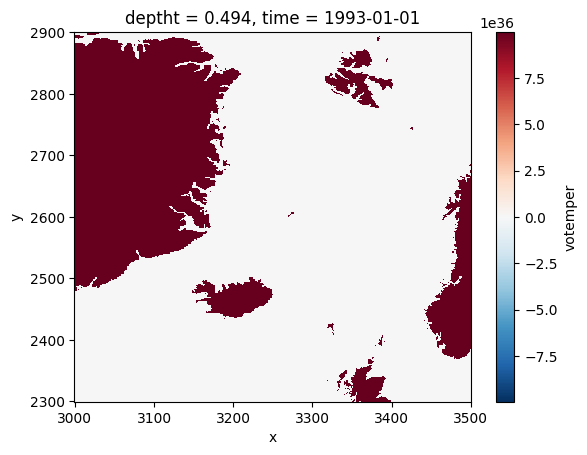

In [18]:
ds_climatology.votemper.isel(time=0, deptht=0).plot()

In [19]:
# Verification: Check that same day of year across different years has the same values
print("Verification: Same day of year should have same values across years")

# Get a sample date and check if it maps correctly
sample_date1 = "1993-01-15"
sample_date2 = "1994-01-15"
sample_date3 = "2000-01-15"

try:
    val1 = ds_climatology["votemper"].sel(time=sample_date1).values
    val2 = ds_climatology["votemper"].sel(time=sample_date2).values
    val3 = ds_climatology["votemper"].sel(time=sample_date3).values

    print(f"Jan 15, 1993 == Jan 15, 1994: {np.allclose(val1, val2)}")
    print(f"Jan 15, 1993 == Jan 15, 2000: {np.allclose(val1, val3)}")
    print(
        "\n✓ Climatology mapping confirmed: Each date references its corresponding day-of-year from ds_averaged!"
    )
except Exception as e:
    print(f"Note: Could not verify with specific dates: {e}")
    print("The climatology references have been created successfully.")

Verification: Same day of year should have same values across years
Jan 15, 1993 == Jan 15, 1994: True
Jan 15, 1993 == Jan 15, 2000: True

✓ Climatology mapping confirmed: Each date references its corresponding day-of-year from ds_averaged!


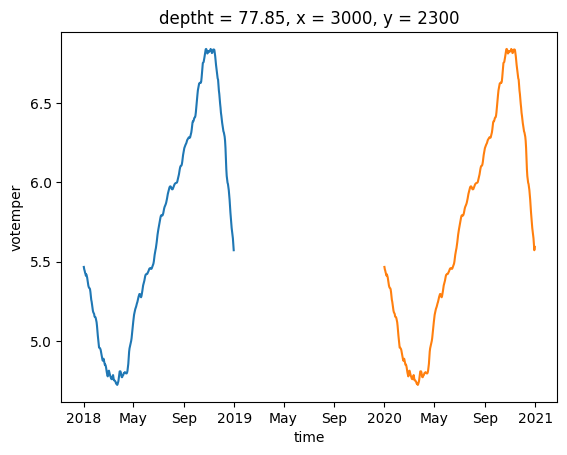

In [21]:
ds_climatology["votemper"].sel(time="2018").isel(deptht=20, y=0, x=0).plot(label="2018")
ds_climatology["votemper"].sel(time="2020").isel(deptht=20, y=0, x=0).plot(label="2020")

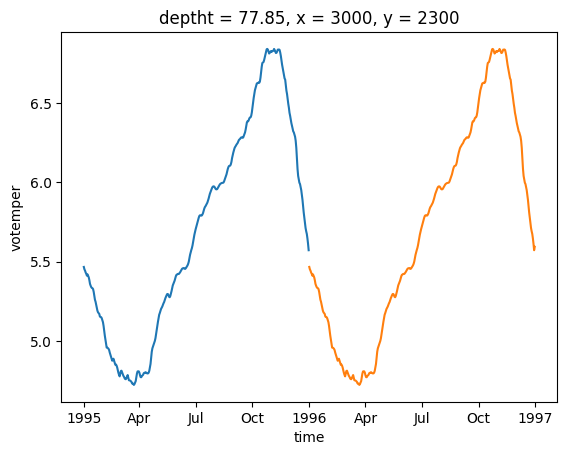

In [ ]:
ds_climatology["votemper"].sel(time="1995").isel(deptht=20, y=0, x=0).plot(label="1995")
ds_climatology["votemper"].sel(time="1996").isel(deptht=20, y=0, x=0).plot(label="1996")

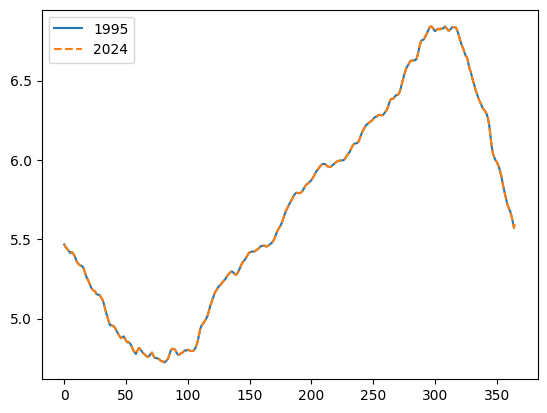

In [11]:
import matplotlib.pyplot as plt

plt.plot(
    ds_climatology["votemper"].sel(time="1995").isel(deptht=20, y=0, x=0),
    linestyle="-",
    label="1995",
)
plt.plot(
    ds_climatology["votemper"].sel(time="2024").isel(deptht=20, y=0, x=0),
    linestyle="--",
    label="2024",
)
plt.legend()